In [ ]:
# =========================================================
# DEMAND FORECASTING + MLFLOW FULL CODE FOR GOOGLE COLAB
# =========================================================

# =========================
# 1. INSTALL LIBRARIES
# =========================
!pip install mlflow pyngrok -q

# =========================
# 2. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# =========================
# 3. MOUNT GOOGLE DRIVE
# =========================
drive.mount('/content/drive')

# =========================
# 4. LOAD DATASET
# =========================

# CHANGE PATH IF NEEDED
df = pd.read_csv('retail_store_inventory.csv')

# =========================
# 5. DISPLAY DATA
# =========================
print("Dataset Shape:")
print(df.shape)

print("\nFirst 5 Rows:")
print(df.head())

print("\nColumns:")
print(df.columns)

# =========================
# 6. HANDLE MISSING VALUES
# =========================
df = df.dropna()

# =========================
# 7. ENCODE CATEGORICAL COLUMNS
# =========================
label_encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = label_encoder.fit_transform(df[column])

# =========================
# 8. DEFINE FEATURES & TARGET
# =========================

# CHANGE TARGET COLUMN NAME IF DIFFERENT
target_column = 'Inventory Level'
X = df.drop(target_column, axis=1)
y = df[target_column]

# =========================
# 9. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =========================
# 10. SET MLFLOW EXPERIMENT
# =========================
mlflow.set_experiment("Demand_Forecasting_Experiment")

# =========================
# 11. START MLFLOW RUN
# =========================
with mlflow.start_run():

    # --------------------------------
    # MODEL PARAMETERS
    # --------------------------------
    n_estimators = 200
    max_depth = 15

    # --------------------------------
    # CREATE MODEL
    # --------------------------------
    model = RandomForestRegressor(
        n_estimators=n_estimators,
        max_depth=max_depth,
        random_state=42
    )

    # --------------------------------
    # TRAIN MODEL
    # --------------------------------
    model.fit(X_train, y_train)

    # --------------------------------
    # PREDICTIONS
    # --------------------------------
    y_pred = model.predict(X_test)

    # --------------------------------
    # EVALUATION
    # --------------------------------
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    # =========================
    # 12. LOG PARAMETERS
    # =========================
    mlflow.log_param("n_estimators", n_estimators)
    mlflow.log_param("max_depth", max_depth)

    # =========================
    # 13. LOG METRICS
    # =========================
    mlflow.log_metric("MAE", mae)
    mlflow.log_metric("MSE", mse)
    mlflow.log_metric("RMSE", rmse)
    mlflow.log_metric("R2_Score", r2)

    # =========================
    # 14. LOG MODEL
    # =========================
    mlflow.sklearn.log_model(
        sk_model=model,
        artifact_path="RandomForestModel"
    )

    # =========================
    # 15. PRINT RESULTS
    # =========================
    print("\n=========== MODEL RESULTS ===========")

    print(f"MAE  : {mae}")
    print(f"MSE  : {mse}")
    print(f"RMSE : {rmse}")
    print(f"R2   : {r2}")

    print("\nMLflow Run Completed Successfully!")

# =========================
# 16. SHOW MLFLOW FILES
# =========================
print("\nMLflow tracking files saved in:")
print("mlruns/")



     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 37.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 887.6/887.6 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.

MessageError: Error: credential propagation was unsuccessful

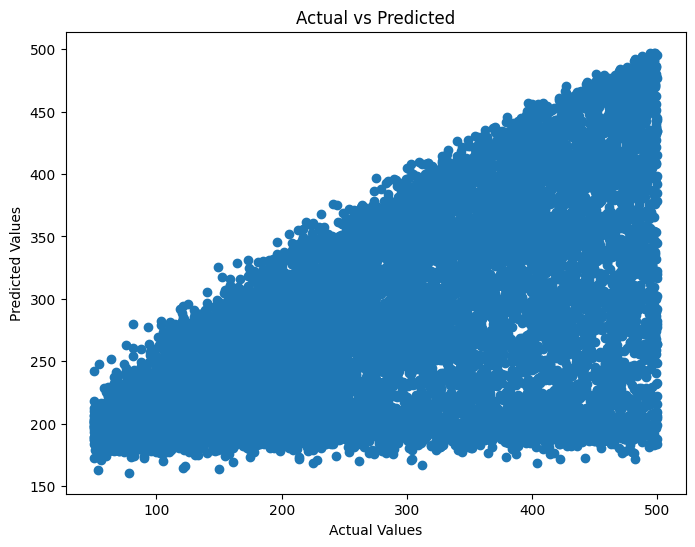

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted")

plt.show()

# SAVE PLOT
plt.savefig("actual_vs_predicted.png")

# LOG TO MLFLOW
mlflow.log_artifact("actual_vs_predicted.png")

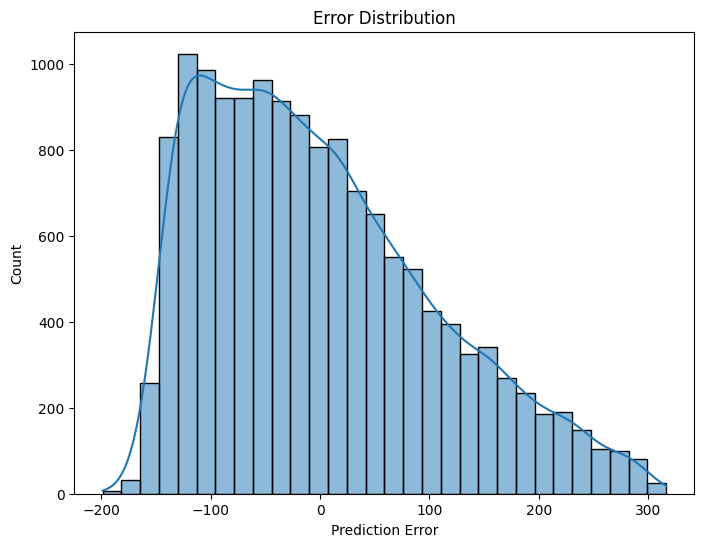

In [ ]:
errors = y_test - y_pred

plt.figure(figsize=(8,6))

sns.histplot(errors, bins=30, kde=True)

plt.xlabel("Prediction Error")
plt.title("Error Distribution")

plt.show()

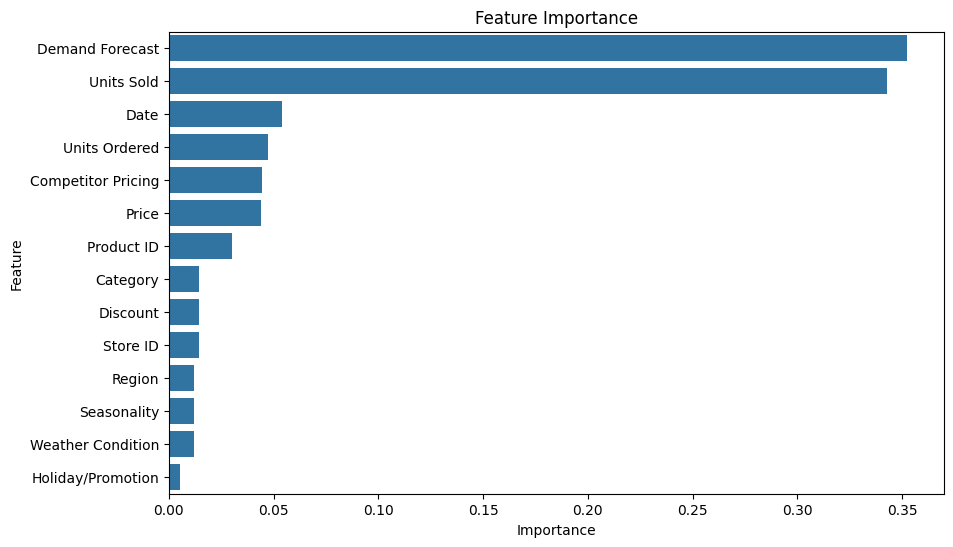

<Figure size 640x480 with 0 Axes>

In [ ]:
# =========================
# 21. FEATURE IMPORTANCE
# =========================
importance = model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance_df
)

plt.title("Feature Importance")

plt.show()

# SAVE PLOT
plt.savefig("feature_importance.png")

# LOG TO MLFLOW
mlflow.log_artifact("feature_importance.png")

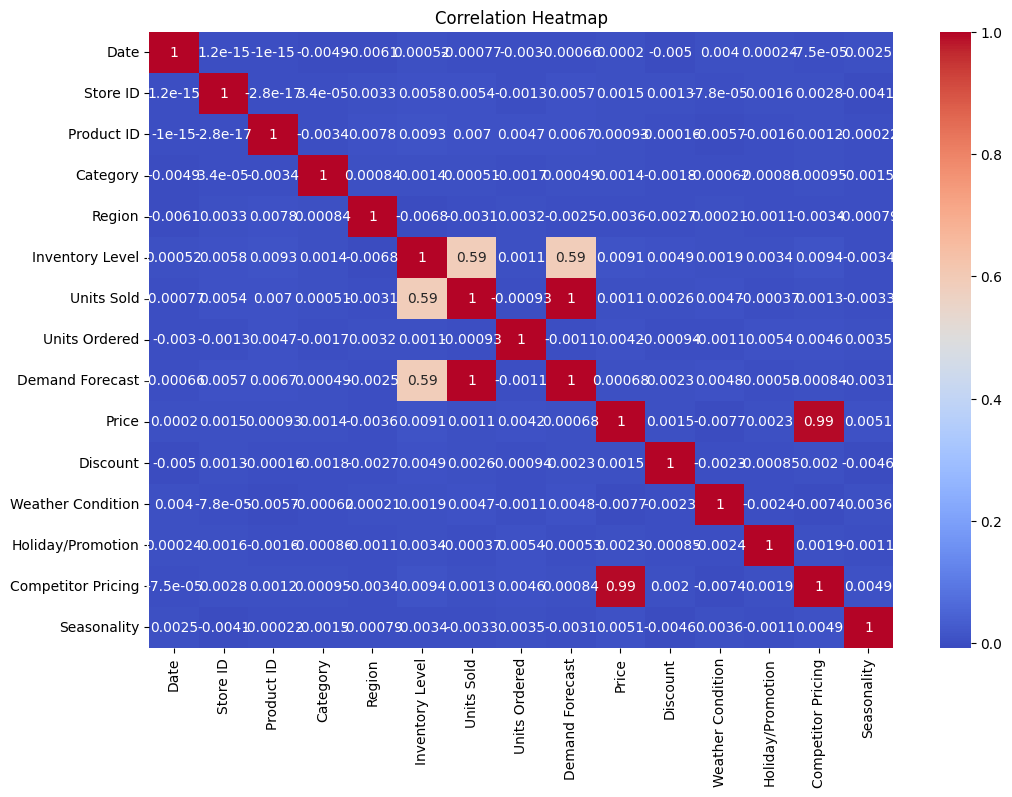

<Figure size 640x480 with 0 Axes>

In [ ]:
# =========================
# 22. CORRELATION HEATMAP
# =========================
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

# SAVE PLOT
plt.savefig("correlation_heatmap.png")

# LOG TO MLFLOW
mlflow.log_artifact("correlation_heatmap.png")

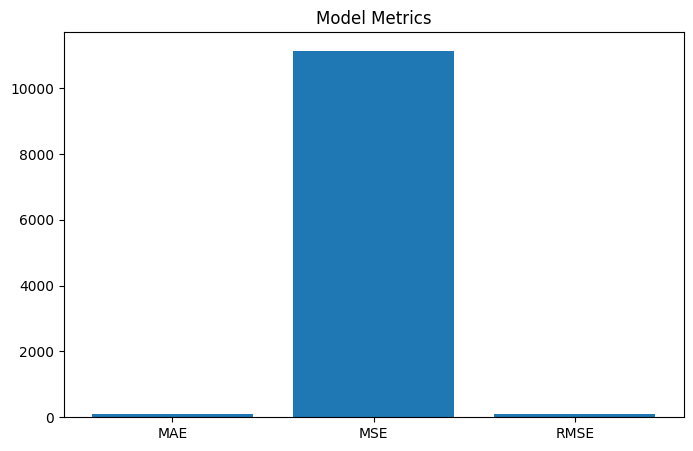

<Figure size 640x480 with 0 Axes>

In [ ]:
# =========================
# 23. METRICS VISUALIZATION
# =========================
metrics = {
    'MAE': mae,
    'MSE': mse,
    'RMSE': rmse
}

plt.figure(figsize=(8,5))

plt.bar(metrics.keys(), metrics.values())

plt.title("Model Metrics")

plt.show()

# SAVE PLOT
plt.savefig("metrics_plot.png")

# LOG TO MLFLOW
mlflow.log_artifact("metrics_plot.png")